In [5]:
from mymodels import mobilenet_v3_small, train, test_error, kCV
from dataUtils import *
from sklearn.model_selection import KFold
from torch.utils.data import Subset
from torch import nn,optim,save,load
import matplotlib.pyplot as plt

device = 'cuda'

In [3]:
model = mobilenet_v3_small(dropout=0.3088235294117647)
model.to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.00025266266504172765)
epochs = 15
dataset = make_train_val_set()
all_loss = kCV(5,dataset,model,loss_fn,optimizer,epochs=epochs,batch_size=32)
save(model.state_dict(), 'models/mobile_net.pth')

FOLD 0
EPOCH 1
	train loss:	 0.03777981007338634
	val. loss:	 0.05296402707695961
EPOCH 2
	train loss:	 0.025927971962991417
	val. loss:	 0.051550620943307875
EPOCH 3
	train loss:	 0.02015297381891584
	val. loss:	 0.050440755188465115
EPOCH 4
	train loss:	 0.018146961528275694
	val. loss:	 0.046704844310879706
EPOCH 5
	train loss:	 0.016273584844050358
	val. loss:	 0.04691152699291706
EPOCH 6
	train loss:	 0.015931193365202267
	val. loss:	 0.052199454754590986
EPOCH 7
	train loss:	 0.014338768263138374
	val. loss:	 0.04743022099137306
EPOCH 8
	train loss:	 0.013426098074497921
	val. loss:	 0.028572805896401404
EPOCH 9
	train loss:	 0.013702015535031654
	val. loss:	 0.014450903031975031
EPOCH 10
	train loss:	 0.012966630039546562
	val. loss:	 0.016276566330343484
EPOCH 11
	train loss:	 0.013017938272761447
	val. loss:	 0.018179593496024608
EPOCH 12
	train loss:	 0.013071696240721005
	val. loss:	 0.013630773089826107
EPOCH 13
	train loss:	 0.01199533568448102
	val. loss:	 0.0148297559097

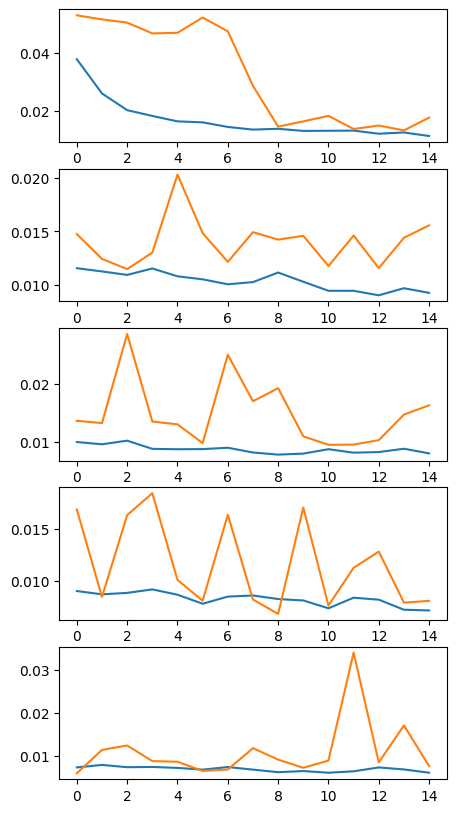

In [6]:
net = mobilenet_v3_small()
net.load_state_dict(load('models/mobile_net.pth',weights_only=True))
all_loss = load_json('results/mobilenet.json')
_, axs = plt.subplots(5,1,figsize=(5,10))
epochs = len(all_loss['all-loss'][0]['train'])
for i,fold in enumerate(all_loss['all-loss']):
    axs[i].plot(range(epochs),fold['train'])
    axs[i].plot(range(epochs),fold['validation'])

In [7]:
cv = all_loss['CV-loss']
test = test_error(net,make_test_set())
validation = all_loss['all-loss'][-1]['validation'][-1]
train = all_loss['all-loss'][-1]['train'][-1]

print(f'train: {train}\nvalid.: {validation}\ntest: {test}\ncv: {cv}')

train: 0.006070941541705052
valid.: 0.007617910346016288
test: 0.007854976421677047
cv: 0.013036889683455228
